### 오차역전파
- 순전파 : 입력층에서부터 출력층까지 정방향으로 이동하여 출력값을 **예측**하는 과정
- 역전파 : 출력층에서 발생한 에러를 입력층쪽으로 전파시키면서 최적의 결과를 위해 가중치를 **학습**해 나가는 과정

### 활성화 함수
- 딥러닝에서 사람처럼 사고하고 행동하도록 실현된 인공지능 기술
- 역치 이상의 자극(값)이 올때만 다음층으로 넘기도록 설정

### 여러가지 활성화 함수
- 초기 활성화 함수로는 'sigmoid'함수를 사용했지만 최적의 해를 찾기위해 미분을 진행하다보니 값이 너무나 작아지는 현상이 발생
- 층이 깊어질수록 'sigmoid'는 값이 너무나 작아져 제대로된 학습이 진행되지 않는 현상이 발생 (Vanishing Gradient(기울기 손실))
- 이런 문제를 해결하기 위해 여러가지 활성화 함수가 탄생

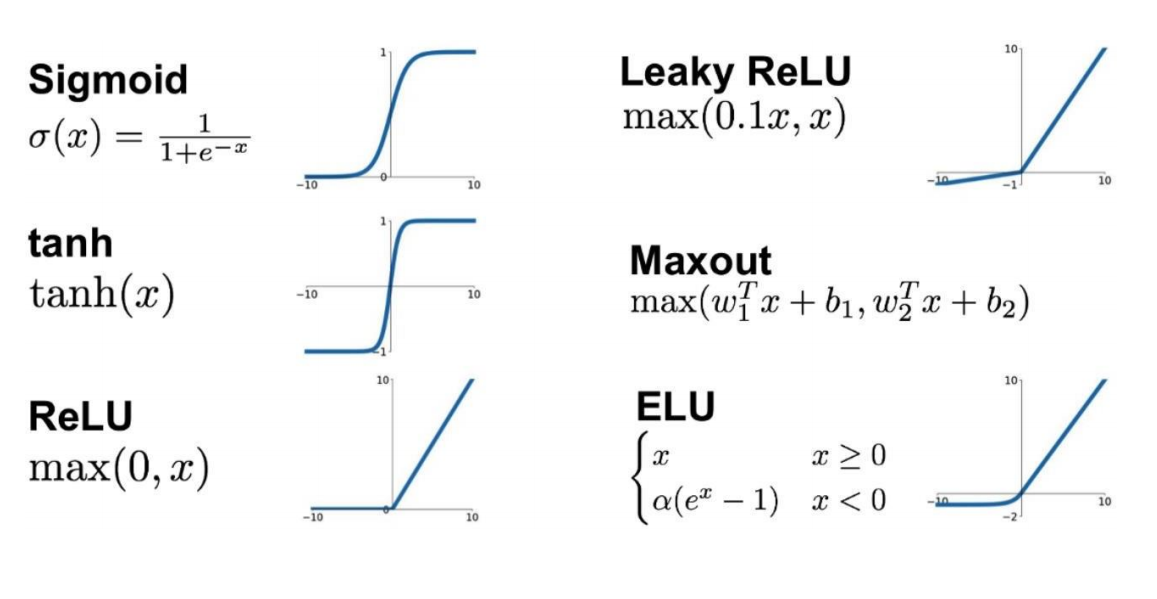

### 최적화 함수(Optimizer)
- 최적의 해(가중치)를 찾기 위해 loss함수를 활용하여 오차가 가장 낮은 쪽으로 학습을 할 수 있도록 도와주는 함수

### 여러가지 최적화 함수
- SGD(확률적 경사하강법) : 확률적으로 선택된 하나의 데이터에 대해 계속하여 업데이트 하면서 최적의 해를 찾아나가는 방법
  - 장점 : 모든 해를 구해서 계산하는 것이 아니기 때문에 속도측면에서 유리하다.
  - 단점 : 업데이트할 때 방향까지 고려하지는 않기 때문에 지그재그 현상이 발생한다.
- 모멘텀(Momentum) : 경사하강법을 사용할 때 이전 방향까지 고려하여 업데이트 하는 방법으로 최적의 값을 찾을 때 좀 더 유연하게 수정해 나가는 방법
  - 지그재그로 이동하는 현상이 줄어든다.
  - 이전 방향을 고려하기 때문에 최적의 값을 찾아내는데 유리하다.
- AdaGrad : 학습률을 점차 줄여나가면서 학습하는 방법
  - 처음에는 크게 학습하여 학습시간을 줄여주고 점차 적게 학습하여 최적의 값을 찾을 때 정확하게 찾는다는 특징이 있음
- Adam : 여러가지 방법의 장점만을 모아서 사용하는 방법
  - 이전방향을 고려하면서 학습률을 점차 줄여가면서 학습


# 손글씨 데이터를 활용하여 다중분류 실습 진행
- 여러가지 활성화함수나 최적화 함수를 활용해 어떤 조합이 가장 좋은 조합인지 확인해보기

### 다중분류
- 다중분류를 하기 위해서는 출력층 퍼셉트론의 개수를 정답의 종류(클래스 개수_와 동일하게 맞춰줘야 한다.(확률값 계산을 위해 각각의 확률이 나올 수 있도록 만들어 주기 위해)
- 출력층에서 사용하는 함수로는 'softmax' 사용
- 정답 데이터를 원핫 인코딩을 진행

### softmax
- 딥러닝에서 다중분류를 진행할 때 각 값의 확률을 출력해주는 함수로서 예측 확률의 합은 1로 설정하여 계산하는 함수
- sigmoid에 비해 오차 평균을 줄여주는 효과를 가진다.

### 목표
- 0~9까지 숫자를 쓴 손글씨 이미지 데이터를 가져와서 어떤 숫자를 쓴건지를 예측하는 다중분류 실습 진행
- 다중분류이기 때문에 출력층이나 loss에서 사용하는 함수 주의!
- 이미지 데이터를 활용

### 이미지 데이터
- 이미지를 이루고 있는 픽셀의 값을 숫자로 변환하여 사용
- 컬러이미지를 변환했을 때 : 3차원의 데이터로 변환
- 흑백이미지를 변환했을 때 : 2차원의 데이터로 변환

In [1]:
# 데이터를 다루기 위한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# tensorflow에서 제공하는 손글씨 데이터 도구 불러오기
from tensorflow.keras.datasets import mnist

In [3]:
# 훈련용, 테스트용 데이터를 나눠서 제공해주기 때문에 해당하는
# 데이터에 맞춰서 불러오기
(X_train, y_train),(X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
# 데이터 크기확인
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
# 학습용 데이터의 개수 : 60000개 / 테스트용 데이터의 개수 : 10000개
# 1개의 데이터 형태 : (28,28) 2차원 데이터 : 흑백 이미지
# 픽셀 : 이미지의 정보를 가지는 가장 단위(이미지를 이루는 가장 작은 단위)
# 1개의 이미지당 28*28 픽셀로 이루어진 것을 확인

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [6]:
# 정답데이터의 종류 확인
np.unique(y_train, return_counts = True)
# 정답데이터의 종류는 0~9까지의 총 10개로 이루어져 있다. (다중 분류)
# 0~9까지의 숫자 중 하나를 예측하기 때문에 출력층의 units의 개수 : 10개
# 출력층의 activation : softmax(다중분류)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

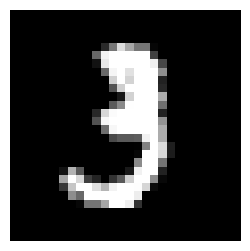

In [7]:
# 데이터 이미지화
# 이미지 크기 설정
plt.figure(figsize=(3,3))
# plt.imshow() : 이미지 데이터를 시각화 할 때 사용
# cmap : 시각화 하는 이미지의 채널 설정 (color / gray)
plt.imshow(X_train[10], cmap='gray')
# plt.axis('off') : X축과 Y축을 안보이도록 설정
plt.axis('off')
plt.show()

In [8]:
y_train[10]

np.uint8(3)

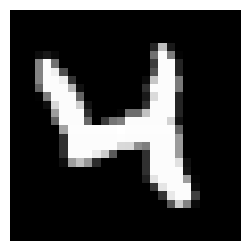

4


In [9]:
# 데이터 이미지화
# 이미지 크기 설정
plt.figure(figsize=(3,3))
# plt.imshow() : 이미지 데이터를 시각화 할 때 사용
# cmap : 시각화 하는 이미지의 채널 설정 (color / gray)
plt.imshow(X_train[20], cmap='gray')
# plt.axis('off') : X축과 Y축을 안보이도록 설정
plt.axis('off')
plt.show()
print(y_train[20])

### 신경망 설계(MLP)
- 손글씨 데이터를 입력받아 어떤 글씨를 썼는지 맞추는 모델을 설계하기

### 주의점
- 우리가 사용하는 정답데이터를 살펴보면 하나의 정수값으로 이루어져 있다.
- 하지만 다중분류에서는 각 정답에 대한 확률값을 출력하기 위해 출력층에서 정답의 수만큼 출력공간을 설정해준다.(units의 수)
- 따라서 정답데이터 또한 정답의 수만큼 컬럼을 늘리기위해 원핫인코딩을 진행한다.

In [10]:
# 원핫인코딩 진행(정답데이터)
# pandas에서 제공하는 get_dummies(data)
y_train_one_hot = pd.get_dummies(y_train, dtype=int)
y_test_one_hot = pd.get_dummies(y_test, dtype=int)

In [12]:
print(y_train[20])
y_train_one_hot.iloc[20]

4


,20
0,0
1,0
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,0


In [3]:
# 신경망 설계를 위한 라이브러리
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten

# Sequential : 뼈대생성을 도와주는 도구
# InputLayer : 입력층을 쌓을 수 있도록 도와주는 도구 중 하나
# Dense : 중간층, 출력층을 쌓도록 돠와주는 도구
# Flatten : 다차원의 데이터를 1차원으로 펴주는 역활

In [16]:
# 모델 설계
# 1. 뼈대생성
model1 = Sequential()

# 입력층 쌓기
# (28,28)의 2차원 데이터가 들어올 수 있도록 설정
model1.add(InputLayer(shape = (28,28,)))
# 일반적으로 MLP층(Dense)층은 1차원의 데이터만 입력 가능
# 따라서 다차원의 데이터가 들어왔을 때 1차원으로 변경을 해줘야 함
# Flatten() : 다차원의 데이터를 1차원으로 변경해주는 역활
model1.add(Flatten())

# 중간층 쌓기 (1차원의 데이터로 변경이 되었기 때문에 사용 가능)
model1.add(Dense(units = 128, activation = 'sigmoid'))
model1.add(Dense(units = 256, activation = 'sigmoid'))
model1.add(Dense(units = 128, activation = 'sigmoid'))

# 출력층 쌓기
model1.add(Dense(units = 10, activation = 'softmax'))
# 출력층의 units의 개수가 10 -> 정답의 class의 종류가 10개이기 때문
# activation = softmax -> 다중분류이기 때문에 확률 계산을 할 수 있도록 하기위해 사용

In [17]:
# 2. 학습방법 및 평가방법 설정
model1.compile(
    # loss : 오차계산방법
    loss = 'categorical_crossentropy',
    # optimizer : 학습방법
    optimizer = 'SGD',
    # metrics : 평가방법
    metrics = ['accuracy']

)

In [18]:
# 학습 진행
model1.fit(X_train, y_train_one_hot,
           epochs = 30,
           validation_split = 0.2,
           batch_size = 32
           )
# batch_size = 32(기본값)
# 데이터를 한번에 학습하기 어렵기 때문에 분할하여 학습하는 방법
# 컴퓨터의 성능에 따라 많이 분할하거나 적게 분할하여 사용
# batch_size가 작을수록 메모리 소모는 작으나 학습속도는 오래걸림
# batch_size가 클 수록 메모리 소모는 크지만 학습속도는 빨라짐
# batch_size가 작을수록 정확도가 올라갈 가능성이 있음

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3434 - loss: 2.1740 - val_accuracy: 0.6198 - val_loss: 1.9655
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6533 - loss: 1.5786 - val_accuracy: 0.7225 - val_loss: 1.1815
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7882 - loss: 0.9409 - val_accuracy: 0.8438 - val_loss: 0.7288
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8541 - loss: 0.6331 - val_accuracy: 0.8784 - val_loss: 0.5257
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8784 - loss: 0.4907 - val_accuracy: 0.8870 - val_loss: 0.4385
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8909 - loss: 0.4226 - val_accuracy: 0.8999 - val_loss: 0.3820
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8980 - loss: 0.3809 - val_accuracy: 0.9051 - val_loss: 0.3618
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9061 - loss: 0.3541 - 

### 결과 시각화

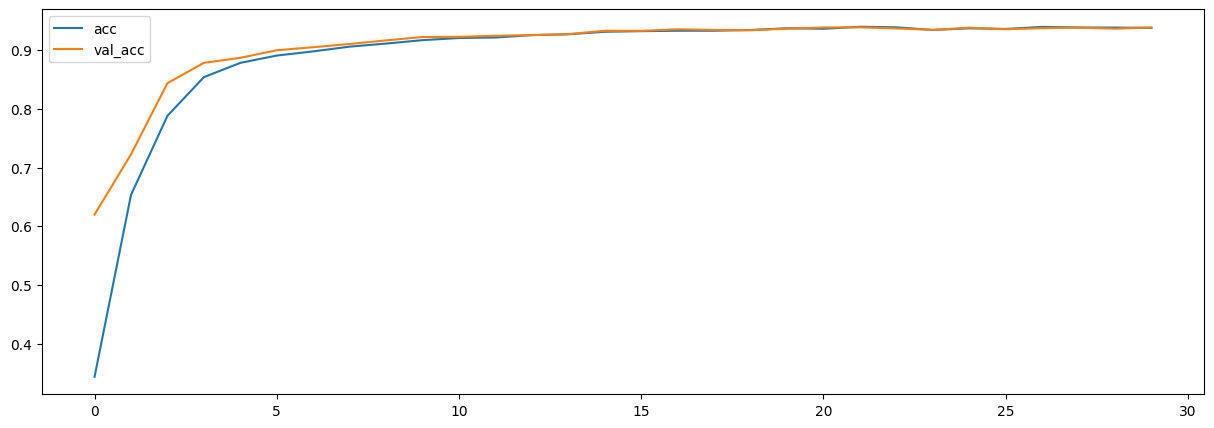

In [19]:
plt.figure(figsize = (15,5))
plt.plot(model1.history.history['accuracy'], label='acc')
plt.plot(model1.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 결과정리
- activation : sigmoid / optimizer : SGD를 사용했을때도 충분한 성능이 나올 수 있음
- 모든 데이터에 대해 sigmoid / SGD쓴다고 해서 무조건 낮은 성능을 보이는 것은 아님

### 패션 데이터 활용
- tensorflow에서 제공하는 패션데이터 활용하여 다중분류 실습 진행

In [4]:
# 패션데이터 불러오기
from tensorflow.keras.datasets import fashion_mnist

# 데이터 로드
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [21]:
# 데이터 확인
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [22]:
# 데이터 확인
X_train[10]

array([[  0,   0,   0,   0,   0,   0,   0,  11, 142, 200, 106,   0,   0,
          0,   0,   0,   0,   0,  85, 185, 112,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 152, 214, 217, 194, 236, 216, 187,
        149, 135, 153, 211, 217, 231, 205, 217, 188,  34,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  66, 185, 166, 180, 181, 190, 211, 221,
        197, 146, 198, 206, 191, 168, 190, 172, 188, 175,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 135, 153, 160, 175, 180, 170, 186, 187,
        190, 188, 190, 187, 174, 195, 185, 174, 161, 175,  59,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 161, 147, 160, 170, 178, 177, 180, 168,
        173, 174, 171, 185, 184, 185, 172, 171, 164, 174, 120,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   2, 175, 146, 145, 168, 178, 181, 185, 180,
        184, 178, 179, 187, 191, 193, 190, 181, 171, 172, 158,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  35, 177, 155, 140, 151, 172, 191, 187, 186,
        187, 186, 187, 182, 191, 194, 188, 180, 161, 161, 185,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  59, 170, 153, 141, 120, 154, 160, 161, 172,
        168, 166, 161, 165, 172, 170, 164, 139, 149, 162, 166,  21,   0,
          0,   0],
       [  0,   0,   0,   0,  79, 145, 160, 214, 123, 128, 153, 160, 164,
        158, 157, 154, 155, 170, 165, 141, 195, 193, 152, 166,  61,   0,
          0,   0],
       [  0,   0,   0,   0, 100, 157, 225, 245, 175, 113, 174, 158, 158,
        160, 155, 160, 164, 178, 188, 135, 185, 240, 201, 172, 108,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  31, 174,  28, 126, 153, 166, 152, 158,
        158, 160, 161, 157, 168, 191, 188,  18, 132, 159,   7,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  82, 187, 159, 153, 157,
        158, 162, 164, 164, 154, 187, 190,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   1,   3,   5,   0,  37, 175, 158, 155, 162,
        158, 160, 162, 165, 153, 177, 205,   0,   0,   3,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   1,   0,  25, 175, 152, 160, 158,
        161, 160, 164, 164, 161, 166, 200,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   4,   0,  30, 171, 147, 164, 155,
        165, 161, 165, 162, 170, 164, 162,   0,   0,   2,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   4,   0,  57, 166, 155, 164, 166,
        161, 161, 164, 167, 165, 165, 162,  28,   0,   3,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   3,   0, 114, 161, 161, 166, 159,
        168, 161, 161, 172, 162, 165, 171,  50,   0,   5,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   1,   0, 149, 157, 167, 172, 159,
        172, 164, 161, 172, 170, 160, 171,  89,   0,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   2,   0,   4, 171, 164, 166, 173, 159,
        179, 166, 160, 174, 167, 162, 166, 128,   0,   2,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   3,   0,  18, 152, 173, 160, 179, 154,
        181, 166, 164, 175, 170, 166, 170, 164,   0,   0,   1,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   4,   0,  47, 165, 172, 167, 185, 153,
        187, 173, 165, 174, 179, 166, 166, 158,   5,   0,   3,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   4,   0,  87, 180, 162, 179, 179, 157,
        191, 182, 165, 168, 190, 173, 165, 166,  20,   0,   4,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   4,   0, 105, 187, 157, 194, 175, 161,
        190, 184, 170, 158, 205, 177, 168, 171,  44,   0,   4,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   5,   0, 138, 181, 158, 205, 160, 167,
        190, 198, 167, 152, 218, 186, 170, 172,  57,   0,   5,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   5,   

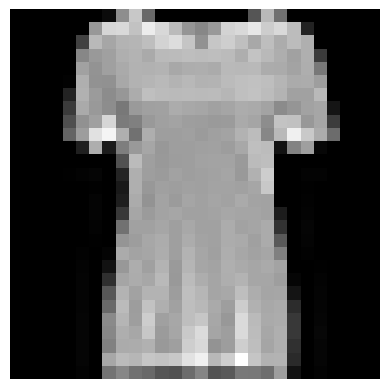

In [24]:
# 데이터 시각화
plt.imshow(X_train[10], cmap='gray')
plt.axis('off')
plt.show()

In [25]:
# 정답 확인
print(y_train[10])

0


### 정답데이터 분류
- 0 : 티셔츠
- 1 : 트라우저(바지)
- 2 : 단추가 없는 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌들
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵클부츠

### 데이터 전처리
- 정답데이터에 대해서 softmax를 이용한 확률값 계산을 하기 때문에 정답의 형태가 클래스의 개수만큼 설정해야 하여 one_hot인코딩을 진행해야 한다

In [5]:
# 원핫 인코딩 진행
y_train_one_hot = pd.get_dummies(y_train, dtype=int)
y_test_one_hot = pd.get_dummies(y_test, dtype=int)

### 신경망 설계
- activation : sigmoid / optimizer : SGD

In [27]:
# 신경망 설계
# 뼈대생성
model1 = Sequential()

# 입력층 쌓기
model1.add(InputLayer(shape = (28,28,)))
# 사용하는 데이터가 1차원이 아니기 때문에 Flatten층을 이용하여 1차원으로 펴주기
model1.add(Flatten())

# 중간층 쌓기
model1.add(Dense(units = 128, activation = 'sigmoid'))
model1.add(Dense(units = 256, activation = 'sigmoid'))
model1.add(Dense(units = 128, activation = 'sigmoid'))

# 출력층 쌓기
model1.add(Dense(units = 10, activation = 'softmax'))

In [28]:
# 학습방법 및 평가방법 설정
model1.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'SGD',
    metrics = ['accuracy']
)

In [29]:
# 학습 진행
model1.fit(
    X_train, y_train_one_hot,
    validation_split = 0.2,
    epochs = 30, batch_size = 32
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3814 - loss: 2.1005 - val_accuracy: 0.5627 - val_loss: 1.7549
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5810 - loss: 1.4178 - val_accuracy: 0.6270 - val_loss: 1.1796
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6410 - loss: 1.0579 - val_accuracy: 0.6575 - val_loss: 0.9459
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6677 - loss: 0.8904 - val_accuracy: 0.6933 - val_loss: 0.8271
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7050 - loss: 0.7955 - val_accuracy: 0.7221 - val_loss: 0.7556
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7360 - loss: 0.7441 - val_accuracy: 0.7348 - val_loss: 0.7375
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7493 - loss: 0.7096 - val_accuracy: 0.7491 - val_loss: 0.7027
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7579 - loss: 0.6767 - 

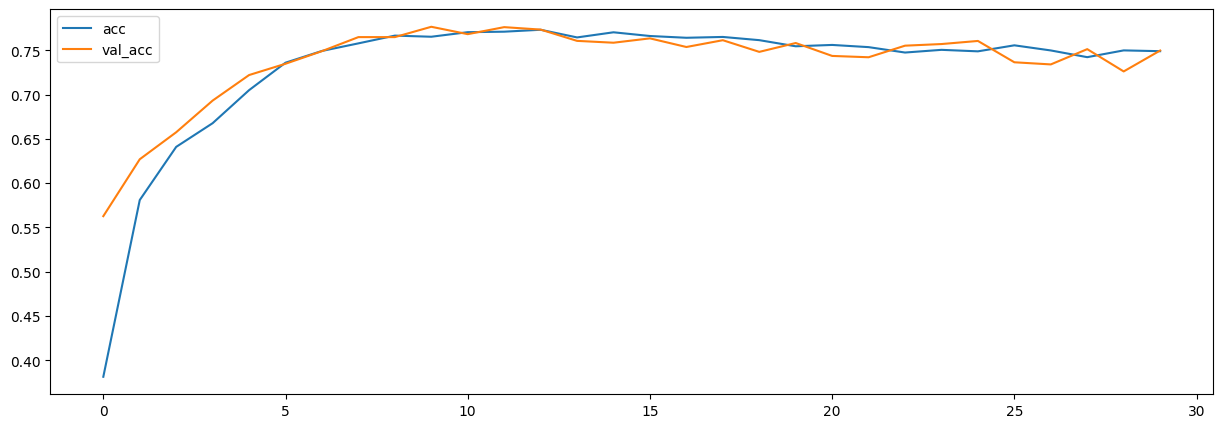

In [30]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model1.history.history['accuracy'], label='acc')
plt.plot(model1.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 정리
- 위에서 사용했던 손글씨 데이터에 비해서 패션데이터는 성능이 높지 않다.
- 따라서 다른 활성화 함수와 최적화 함수의 조합으로 모델을 설계해보자.

### 2. activation : relu / optimizer : SGD를 사용하여 신경망 설계

In [33]:
# 신경망 설계
# 뼈대생성
model2 = Sequential()

# 입력층 쌓기
model2.add(InputLayer(shape = (28,28,)))
# 사용하는 데이터가 1차원이 아니기 때문에 Flatten층을 이용하여 1차원으로 펴주기
model2.add(Flatten())

# 중간층 쌓기
model2.add(Dense(units = 128, activation = 'relu'))
model2.add(Dense(units = 256, activation = 'relu'))
model2.add(Dense(units = 128, activation = 'relu'))

# 출력층 쌓기
model2.add(Dense(units = 10, activation = 'softmax'))

# 학습방법 및 평가 방법 설정
model2.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'SGD',
    metrics = ['accuracy']
)

# 학습
model2.fit(X_train, y_train_one_hot,
           validation_split=0.2, epochs = 30)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0992 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.0993 - loss: nan - val_accuracy: 0.1030 - val_loss: nan
Epoch 9/

### 3. activation : relu / optimizer : adam을 사용하여 신경망 설계

In [34]:
# 신경망 설계
# 뼈대생성
model3 = Sequential()

# 입력층 쌓기
model3.add(InputLayer(shape = (28,28,)))
# 사용하는 데이터가 1차원이 아니기 때문에 Flatten층을 이용하여 1차원으로 펴주기
model3.add(Flatten())

# 중간층 쌓기
model3.add(Dense(units = 128, activation = 'relu'))
model3.add(Dense(units = 256, activation = 'relu'))
model3.add(Dense(units = 128, activation = 'relu'))

# 출력층 쌓기
model3.add(Dense(units = 10, activation = 'softmax'))

# 학습방법 및 평가 방법 설정
model3.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

# 학습
model3.fit(X_train, y_train_one_hot,
           validation_split=0.2, epochs = 30)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7506 - loss: 1.4154 - val_accuracy: 0.7988 - val_loss: 0.5919
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8152 - loss: 0.5340 - val_accuracy: 0.8175 - val_loss: 0.5206
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8363 - loss: 0.4666 - val_accuracy: 0.8484 - val_loss: 0.4369
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8505 - loss: 0.4237 - val_accuracy: 0.8473 - val_loss: 0.4306
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8569 - loss: 0.4048 - val_accuracy: 0.8440 - val_loss: 0.4567
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8597 - loss: 0.3880 - val_accuracy: 0.8614 - val_loss: 0.4124
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8644 - loss: 0.3768 - val_accuracy: 0.8648 - val_loss: 0.3899
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8651 - loss: 0.3709 -

### 모델비교

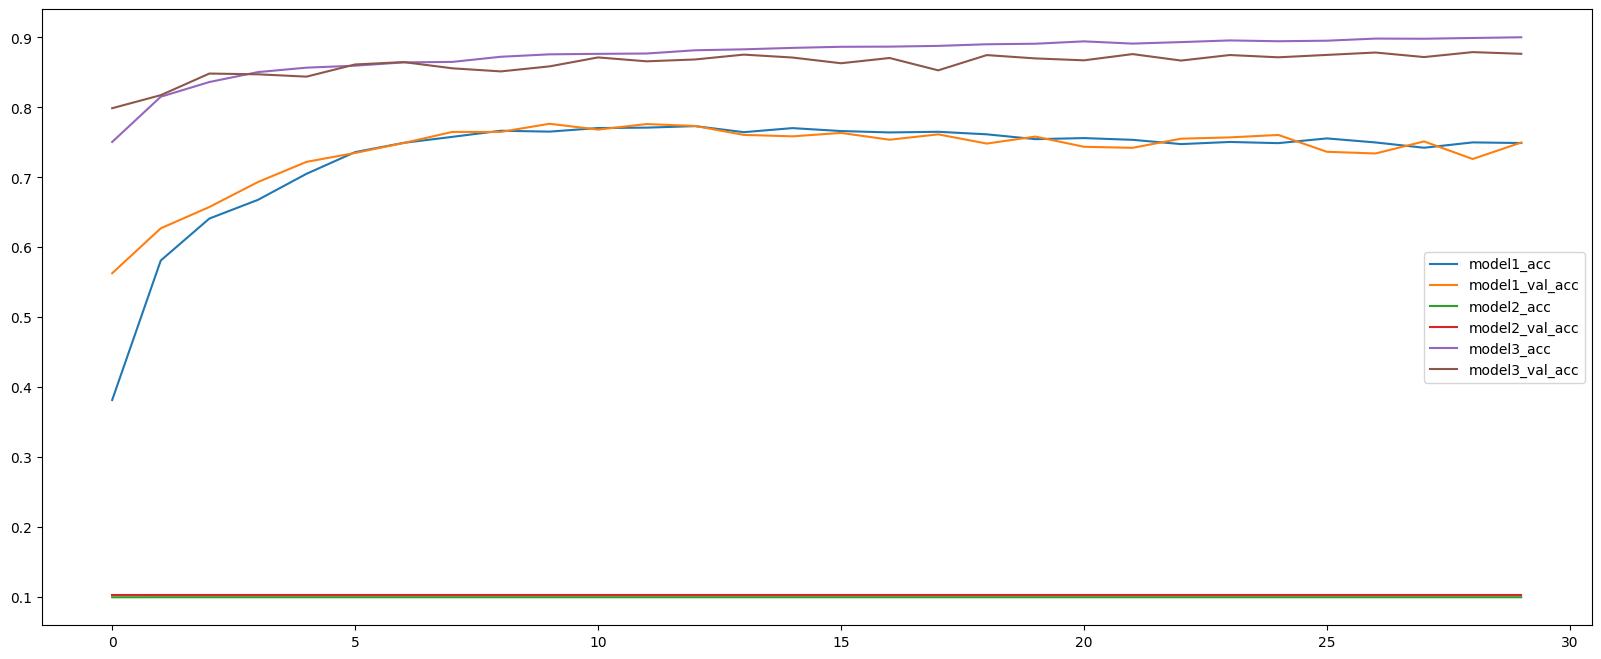

In [35]:
plt.figure(figsize=(20,8))

# 1번모델 시각화
plt.plot(model1.history.history['accuracy'], label='model1_acc')
plt.plot(model1.history.history['val_accuracy'], label='model1_val_acc')

# 2번모델 시각화
plt.plot(model2.history.history['accuracy'], label='model2_acc')
plt.plot(model2.history.history['val_accuracy'], label='model2_val_acc')

# 3번모델 시각화
plt.plot(model3.history.history['accuracy'], label='model3_acc')
plt.plot(model3.history.history['val_accuracy'], label='model3_val_acc')

plt.legend()
plt.show()

### 시각화 결과
- 3개의 모델을 비교했더니 가장 높은 성능을 내는 모델은 3번 모델이다.
- activation : relu / optimizer : adam
- 모든 경우에도 reul/adam조합이 좋은지는 확인이 필요하다. 하지만 경험적 측면에서 일반적으로 relu/adam이 성능이 높을 가능성이 있다.

### 출력층의 활성화 함수와 손실함수 정리
- 회귀문제 -> units : 1개 / 출력층 activation : linear / loss : MSE
- 이진분류 -> units : 1개 / 출력층 activation : sigmoid / loss : binary_crossentropy
- 다중분류 -> units : 정답의 종류(class의 수) / 출력층 activation : softmax / loss : categorical_crossentropy

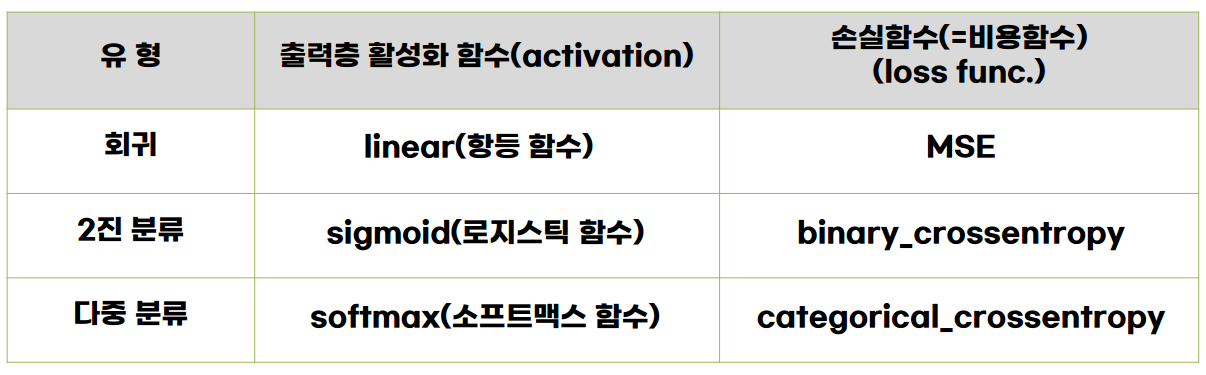

In [7]:
# 신경망 설계
# 뼈대생성
model3 = Sequential()

# 입력층 쌓기
model3.add(InputLayer(shape = (28,28,)))
# 사용하는 데이터가 1차원이 아니기 때문에 Flatten층을 이용하여 1차원으로 펴주기
model3.add(Flatten())

# 중간층 쌓기
model3.add(Dense(units = 128, activation = 'relu'))
model3.add(Dense(units = 256, activation = 'relu'))
model3.add(Dense(units = 128, activation = 'relu'))

# 출력층 쌓기
model3.add(Dense(units = 10, activation = 'softmax'))

# 학습방법 및 평가 방법 설정
model3.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

# 학습
model3.fit(X_train, y_train_one_hot,
           validation_split=0.2, epochs = 100)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7469 - loss: 1.5751 - val_accuracy: 0.7366 - val_loss: 0.7855
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8131 - loss: 0.5363 - val_accuracy: 0.8264 - val_loss: 0.4969
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8353 - loss: 0.4640 - val_accuracy: 0.8407 - val_loss: 0.4563
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8458 - loss: 0.4302 - val_accuracy: 0.8454 - val_loss: 0.4192
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8537 - loss: 0.4029 - val_accuracy: 0.8481 - val_loss: 0.4258
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8580 - loss: 0.3905 - val_accuracy: 0.8548 - val_loss: 0.4026
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8642 - loss: 0.3764 - val_accuracy: 0.8487 - val_loss: 0.4304
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8675 - loss: 

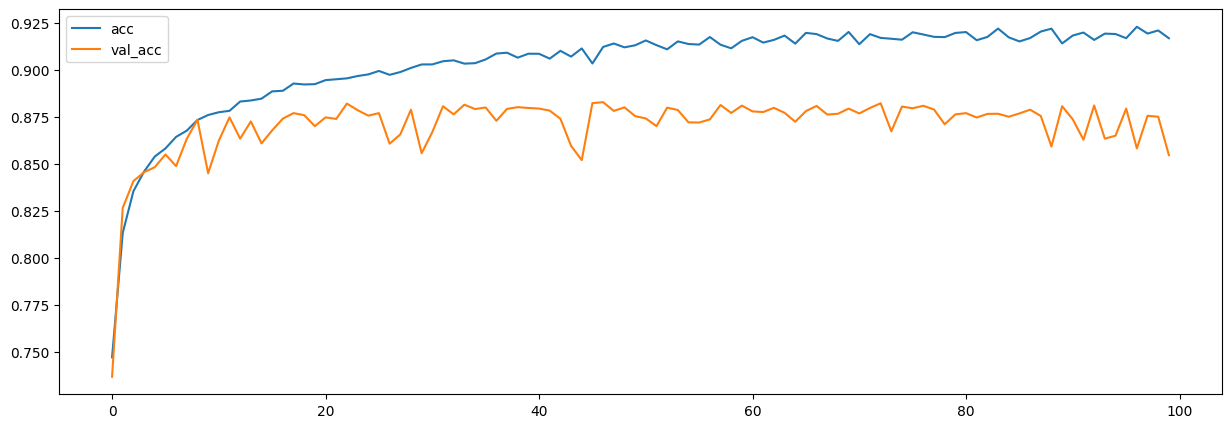

In [8]:
# 시각화 진행
plt.figure(figsize=(15,5))
plt.plot(model3.history.history['accuracy'], label='acc')
plt.plot(model3.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### EarlyStopping(얼리스탑핑)
- 조기학습중단
- 모델을 학습할 때 성능이 더이상 오르지 않는 구간이 있을 때도 계속하여 학습을 진행하면 시간 및 자원 낭비가 일어나며 과대적합이 일어날 수 있음
- 더이상 성능이 오르지 않는다고 판단이 되면 내가 설정한 epochs를 전부 학습하는 것이 아니라 중간에 학습을 중단하는 기능
- 과적합을 어느정도 방지하며 시간과 자원낭비를 줄일 수 있음

In [9]:
# 도구 불러오기
from tensorflow.keras.callbacks import EarlyStopping

In [10]:
# 얼리스탑핑 사용
early_stop = EarlyStopping(
    # monitor : 조기종료 할 때 어떤 기준을 가지고 종료할 지 설정(기준값)
    monitor = 'val_accuracy',
    # patience : 몇번의 학습동안 성능개선이 안될 경우 종료할 지 설정
    patience = 5
)
# 학습이 돌아갈 때 5번동안 성능개선이 안되면 학습을 중단하도록 설정

In [11]:
# 학습진행 (얼리스탑핑 설정)
model3.fit(
    X_train, y_train_one_hot,
    validation_split = 0.2,
    epochs = 100,
    callbacks = [early_stop]
)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9173 - loss: 0.2328 - val_accuracy: 0.8773 - val_loss: 0.8022
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9249 - loss: 0.2184 - val_accuracy: 0.8801 - val_loss: 0.8027
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9204 - loss: 0.2285 - val_accuracy: 0.8801 - val_loss: 0.7170
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9229 - loss: 0.2199 - val_accuracy: 0.8747 - val_loss: 0.7132
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9196 - loss: 0.2304 - val_accuracy: 0.8767 - val_loss: 0.7684
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9217 - loss: 0.2268 - val_accuracy: 0.8756 - val_loss: 0.7428
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9251 - loss: 0.2109 - val_accuracy: 0.8713 - val_loss: 0.7332
